# 1. pre-process

Input: 
1. <dataset_name>_participants.tsv: 
dataset	| participant_id | participant_exp (in original dataset)| age_months (postnatal)	
BCP     | sub-001        | NCBCP388560_v01-1-2wk-20170309       | 0.46
2. T1w and T2w images:
for each row in <dataset_name>_participants.tsv: 
row['participant_id']_T1w.nii.gz, row['participant_id']_T2w.nii.gz


Note:
For now, only includes subjects with gestational age >=37 weeks


Process:
1. iBEAT (16h for BCP, 1.5~3h for dHCP)
2. 


## 1.1 Got subject age

In [1]:
from __future__ import print_function

import os
import re
import glob
import subprocess
import shutil
import json
import pandas as pd
import numpy as np
from tqdm import tqdm

### iso_dHCP:
Isolation: 40 dHCP subjects 

In [15]:
import pandas as pd

iso_info = pd.read_csv("/project/4290000.01/yapwan/Projects/CerebellarIsolation/data/dHCP_info.csv", sep=',')
iso_age = iso_info[iso_info['nscan_ga_at_birth_weeks']>=37].copy()

# Convert age to months
iso_age['age_months'] = (iso_age['postnatal_age_weeks'] * 7)/30.437
iso_age


,participant_id,src_subject_id,scan_validation,sex,nscan_ga_at_birth_weeks,nscan_ga_at_scan_weeks,postnatal_age_weeks,age_months
10,sub-11,sub-CC00120XX05,41600,M,39.857143,40.142857,0.285714,0.065709
11,sub-12,sub-CC00320XX07,102300,F,40.142857,40.285714,0.142857,0.032855
12,sub-13,sub-CC00409XX13,125600,M,40.714286,41.000000,0.285714,0.065709
13,sub-14,sub-CC00583XX15,178600,F,40.428571,42.000000,1.571429,0.361402
14,sub-15,sub-CC00656XX13,217601,F,42.285714,43.000000,0.714286,0.164274
15,sub-16,sub-CC00799XX25,23810,M,42.000000,44.000000,2.000000,0.459966
16,sub-17,sub-CC00200XX02,67204,M,40.285714,44.428571,4.142857,0.952788
17,sub-18,sub-CC00480XX11,141609,F,41.142857,44.000000,2.857143,0.657095
18,sub-19,sub-CC00176XX12,57600,M,41.285714,43.571429,2.285714,0.525676
19,sub-20,sub-CC00252XX05,84000,M,40.142857,43.142857,3.000000,0.689950


In [16]:
iso_age['0-1M'] = False
iso_age.loc[iso_age['age_months'] <= 1, '0-1M']=True 

# First postnatal year
max_month = 12        # upper bound
window_width = 1      # sliding window size (months)
age_col = "age_months"
for start in range(0, max_month - window_width + 2):
    col_name = f"{start}-{start + window_width}M"

    iso_age[col_name] = (
        (iso_age[age_col] >= start) & # 
        (iso_age[age_col] <= start + window_width)
    )


window_cols = [c for c in iso_age.columns if "-" in c and c.endswith("M")]

counts = iso_age[window_cols].sum()
print(counts)

0-1M      29
1-2M       1
2-3M       0
3-4M       0
4-5M       0
5-6M       0
6-7M       0
7-8M       0
8-9M       0
9-10M      0
10-11M     0
11-12M     0
12-13M     0
dtype: int64


In [17]:
# save as participants.tsv
iso_age.to_csv(os.path.join('/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info', 'iso_participants.tsv'), sep='\t', index=False)


In [3]:
# Copy input files to output directory
import os
import sys
import shutil

dataset_name = 'iso'
# Configuration
data_dir = "/project/4290000.01/yapwan/Projects/CerebellarIsolation/data"
# pipel_dir = "/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/scripts/neonatal_transf_share/ExampleData"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
ibeat_dir = "/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP_all"

for dataset_name in ['iso']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    for subid in info_age['participant_id']:
        # output_dir = f"{pipel_dir}/{subid}/"
        output_dir = os.path.join(pipel_dir, dataset_name, subid)
        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)

        ibeat_T1 = f"{ibeat_dir}/{subid}/T1-skullstripped.nii.gz"
        ibeat_T2 = f"{ibeat_dir}/{subid}/T2-skullstripped.nii.gz"
        if not os.path.exists(ibeat_T1) or not os.path.exists(ibeat_T2):
            print(f"Warning: Missing T1 or T2 for subject {subid} in age bin {m_bin}.")
            ibeat_T1 = f"/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP/{subid}/T1-skullstripped.nii.gz"
            ibeat_T2 = f"/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP/{subid}/T2-skullstripped.nii.gz"
            
        brain_img_T1 = os.path.join(output_dir, f'T1-skullstripped.nii.gz')
        brain_img_T2 = os.path.join(output_dir, f'T2-skullstripped.nii.gz')
        # Copy ibeat_T1 to brain_img_T1
        shutil.copy(ibeat_T1, brain_img_T1)
        # Copy ibeat_T2 to brain_img_T2
        shutil.copy(ibeat_T2, brain_img_T2)
        print(f"Copied {ibeat_T1} to {brain_img_T1}")


Processing dataset: iso
Copied /project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP_all/sub-11/T1-skullstripped.nii.gz to /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1-skullstripped.nii.gz
Copied /project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP_all/sub-12/T1-skullstripped.nii.gz to /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-12/T1-skullstripped.nii.gz
Copied /project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP_all/sub-13/T1-skullstripped.nii.gz to /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-13/T1-skullstripped.nii.gz
Copied /project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ibeat_data/results/dHCP_all/sub-14/T1-skullstripped.nii.gz to /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-14/T1-skullstripped.nii.gz
Copied /proj

## 1.3 Padding and re-orient if necessary
Open to check whether re-orientation and pad

In [6]:
import os
import sys
from tqdm import tqdm
import pandas as pd
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
tpl_dirs = [d for d in os.listdir(tpl_root) if os.path.isdir(os.path.join(tpl_root, d))]
tpl_months = sorted([d.replace("Month", "") for d in tpl_dirs if d.endswith("Month")], key=int)

base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import translate_pair_to_template_space

for dataset_name in ['iso']: # ,'dHCP'
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:1]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        # for subid in tqdm(subs_pos):
        for subid in tqdm(subs[m_bin]):
            print(f"Processing subject: {subid}")
            pipel_dir_cur = os.path.join(pipel_dir, dataset_name, subid)
            template_img_path = os.path.join(tpl_root, "00Month", "BCP-00M-T1.nii.gz")
            t1_img_path = os.path.join(pipel_dir_cur, f"T1-skullstripped.nii.gz")
            t1_output_path = os.path.join(pipel_dir_cur, f"T1_Brain_pad.nii.gz")
            t2_img_path = os.path.join(pipel_dir_cur, f"T2-skullstripped.nii.gz")
            t2_output_path = os.path.join(pipel_dir_cur, f"T2_Brain_pad.nii.gz")
            translate_pair_to_template_space(
                    t1_img_path = t1_img_path,
                    t2_img_path = t2_img_path,
                    fix_img_path = template_img_path,
                    t1_output_path = t1_output_path,
                    t2_output_path= t2_output_path,
                )


Processing dataset: iso
Subjects in age bin 0-1M: 29


  0%|          | 0/29 [00:00<?, ?it/s]

Processing subject: sub-11
T1 shape: [218 289 289] spacing: [0.5 0.5 0.5]
target shape: [389 466 317]
T1 COM: [109.08638663 130.45420415 152.88814621]
shift_vox: [ 85 102   5]
placed into canvas
affine constructed


  3%|▎         | 1/29 [00:11<05:25, 11.62s/it]

[SAVE] T1 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1_Brain_pad.nii.gz
[SAVE] T2 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T2_Brain_pad.nii.gz
Processing subject: sub-12
T1 shape: [218 289 289] spacing: [0.5 0.5 0.5]
target shape: [389 466 317]
T1 COM: [107.77971701 118.45264732 155.12552086]
shift_vox: [ 86 114   3]
placed into canvas
affine constructed


...

[SAVE] T1 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-38/T1_Brain_pad.nii.gz
[SAVE] T2 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-38/T2_Brain_pad.nii.gz
Processing subject: sub-39
T1 shape: [218 289 289] spacing: [0.5 0.5 0.5]
target shape: [389 466 317]
T1 COM: [111.87224769 132.74374695 154.64982992]
shift_vox: [ 82 100   3]
placed into canvas
affine constructed


 97%|█████████▋| 28/29 [04:48<00:10, 10.11s/it]

[SAVE] T1 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T1_Brain_pad.nii.gz
[SAVE] T2 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T2_Brain_pad.nii.gz
Processing subject: sub-40
T1 shape: [218 289 289] spacing: [0.5 0.5 0.5]
target shape: [389 466 317]
T1 COM: [122.04424015 127.19501444 148.78355955]
shift_vox: [ 72 105   9]
placed into canvas
affine constructed


100%|██████████| 29/29 [04:58<00:00, 10.30s/it]

[SAVE] T1 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-40/T1_Brain_pad.nii.gz
[SAVE] T2 -> /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-40/T2_Brain_pad.nii.gz


In [9]:
# Before padding
import nibabel as nib
import numpy as np
from tqdm import tqdm
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'

print(f"{'SubjID':>10} | {'Voxel Shape':>15} | {'Spacing (mm)':>14}| {'World Size (mm)':>19} | {'Origin (mm)':>15} ")
print("-" * 120)

for dataset_name in ['dHCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:2]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        # for subid in tqdm(subs_pos):
        for subid in subs[m_bin]:
            pipel_dir_cur = os.path.join(pipel_dir, dataset_name, subid)
            subj_img_path = os.path.join(pipel_dir_cur, f"T1-skullstripped.nii.gz")
            
            img = nib.load(subj_img_path)
            hdr = img.header
            affine = img.affine

            shape = np.array(img.shape)
            spacing = np.array(hdr.get_zooms()[:3])
            origin = affine[:3, 3]  # translation part of affine matrix
            world_size = np.linalg.norm(affine[:3, :3], axis=0) * shape

            print(f"{subid:>10} | {str(shape):>15} | {np.round(spacing,3)} | {np.round(world_size,1)} | {np.round(origin,3)}")

    SubjID |     Voxel Shape |   Spacing (mm)|     World Size (mm) |     Origin (mm) 
------------------------------------------------------------------------------------------------------------------------
Processing dataset: dHCP
Subjects in age bin 0-1M: 30
   sub-001 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-59.    -62.25  -59.742]
   sub-002 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-58.582 -69.357 -55.979]
   sub-003 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-60.254 -62.25  -53.053]
   sub-004 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-66.525 -65.176 -71.447]
   sub-005 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-53.147 -68.103 -55.561]
   sub-006 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-58.164 -57.233 -47.2  ]
   sub-007 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-55.237 -63.086 -56.397]
   sub-008 |   [217 290 290] | [0.5 0.5 0.5] | [108.5 145.  145. ] | [-58.

In [10]:
# Before padding
import nibabel as nib
import numpy as np
from tqdm import tqdm
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
print(f"{'SubjID':>10} | {'Voxel Shape':>15} | {'Spacing (mm)':>14}| {'World Size (mm)':>19} | {'Origin (mm)':>15} ")
print("-" * 120)

for dataset_name in ['dHCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join('/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info', f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:2]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        # for subid in tqdm(subs_pos):
        for subid in subs[m_bin]:
            pipel_dir_cur = os.path.join(pipel_dir, dataset_name, subid)
            subj_img_path = os.path.join(pipel_dir_cur, f"T1_Brain_pad.nii.gz")
            
            img = nib.load(subj_img_path)
            hdr = img.header
            affine = img.affine

            shape = np.array(img.shape)
            spacing = np.array(hdr.get_zooms()[:3])
            origin = affine[:3, 3]  # translation part of affine matrix
            world_size = np.linalg.norm(affine[:3, :3], axis=0) * shape

            print(f"{subid:>10} | {str(shape):>15} | {np.round(spacing,3)} | {np.round(world_size,1)} | {np.round(origin,3)}")

    SubjID |     Voxel Shape |   Spacing (mm)|     World Size (mm) |     Origin (mm) 
------------------------------------------------------------------------------------------------------------------------
Processing dataset: dHCP
Subjects in age bin 0-1M: 30
   sub-001 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-002 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-003 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-004 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-005 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-006 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-007 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96.2  -134.25  -72.2 ]
   sub-008 |   [389 466 317] | [0.5 0.5 0.5] | [194.5 233.  158.5] | [ -96

FileNotFoundError: No such file or no access: '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/dHCP/sub-031/T1_Brain_pad.nii.gz'

# 3. direct: subj->tpl direct transfer

In [7]:
import os
import sys
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import multimodal_register_pipeline
from tqdm import tqdm
import pandas as pd

pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"


for dataset_name in ['iso','dHCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:1]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
        print(f'Tpl month: {tpl_months}')


        for tpl_month in tpl_months:
            print(f"Running registration → tpl_month={tpl_month}")

            for subid in subs[m_bin]:
                output_dir = os.path.join(pipel_dir, dataset_name, subid)
                input_files = {
                    "T1": f"{output_dir}/T1_Brain_pad.nii.gz",
                    "T2": f"{output_dir}/T2_Brain_pad.nii.gz"
                }

                multimodal_register_pipeline(
                    modalities=["T1", "T2"],
                    input_files=input_files,
                    tpl_root=tpl_root,
                    tpl_month=tpl_month,
                    output_dir=output_dir,
                    steps=[1,2,3],  # 2, 3 are necessary because need the direct JD
                    slurm=True
                )

Processing dataset: iso
Subjects in age bin 0-1M: 29
Tpl month: ['00', '01']
Running registration → tpl_month=00
[INFO] Submitting job: T1T2_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/log/T1T2_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/log/T1T2_00Mtpl.sh
Submitted batch job 51456709
[INFO] Submitting job: T1T2_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-12/log/T1T2_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-12/log/T1T2_00Mtpl.sh
Submitted batch job 51456710
[INFO] Submitting job: T1T2_00Mtpl
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-13/log/T1T2_00Mtpl.sh
[INFO] Command: sbatch /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-13/log/T1T2_00Mtpl.sh
Submitted batch job 51456711
[INFO] Subm

29it [00:34,  1.18s/it]
30it [00:36,  1.20s/it]


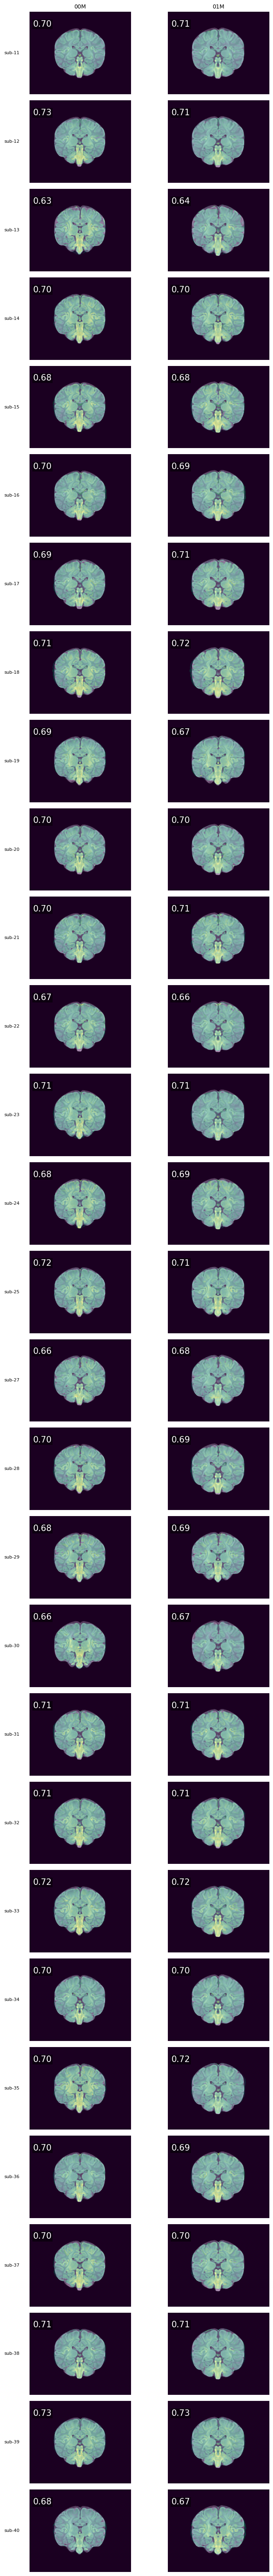

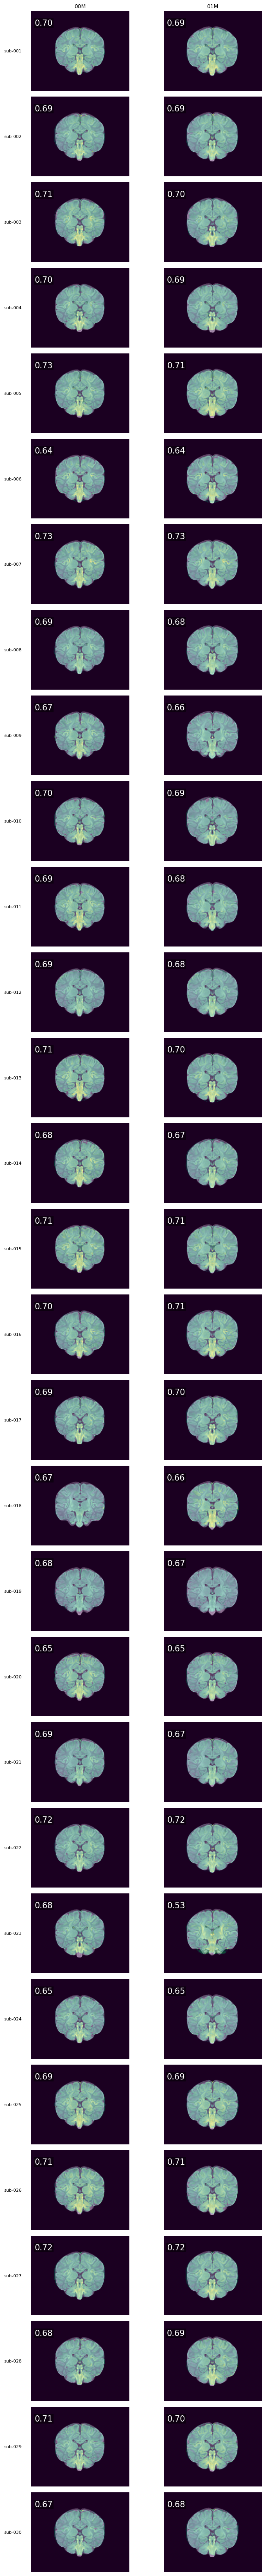

In [ ]:
import os
import pandas as pd
import ants
import matplotlib.pyplot as plt
from tqdm import tqdm

pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
sub_check = {}
tomonth = 1
for dataset_name in ['iso', 'dHCP']:
    sub_check[dataset_name] = []
    info_age = pd.read_csv(
        os.path.join(Info_dir, f'{dataset_name}_participants.tsv'),
        sep='\t'
    )

    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]

    subs = {
        w: info_age.loc[info_age[w], "participant_id"].drop_duplicates().values
        for w in window_cols
    }

    for m_bin in window_cols[:tomonth]:

        tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),
                      m_bin.replace("M","").split("-")[1].zfill(2)]

        # ---------- preload templates ----------
        tpl_dict = {}
        msk_dict = {}
        for tpl_month in tpl_months:
            tpl_file = os.path.join(
                tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-T1.nii.gz"
            )
            mask_file = os.path.join(
                    tpl_root, f"{tpl_month}Month", f"BCP-{tpl_month}M-Mask.nii.gz"
                )
            tpl_dict[tpl_month] = ants.image_read(tpl_file).numpy()
            msk_dict[tpl_month] = ants.image_read(mask_file).numpy()


        n_subj = len(subs[m_bin])
        n_cols = len(tpl_months)

        fig, axes = plt.subplots(
            n_subj, n_cols,
            figsize=(4 * n_cols, 2.2 * n_subj),
            squeeze=False
        )

        for i, subid in tqdm(enumerate(subs[m_bin])):

            output_dir = os.path.join(pipel_dir, dataset_name, subid)

            for j, tpl_month in enumerate(tpl_months):

                registered_img_path = os.path.join(
                    output_dir,
                    f"T1_Brain_pad_Norm_to_{tpl_month}Mtpl_Warped.nii.gz"
                )

                if not os.path.exists(registered_img_path):
                    continue

                img_np = ants.image_read(registered_img_path).numpy()
                tpl_np = tpl_dict[tpl_month]

                ax = axes[i, j]
                ax.axis('off')

                # ---------- use consistent axial slice ----------
                # sl = img_np.shape[1] // 2
                sl = np.argmax(img_np.sum(axis=(0,2)))

                ax.imshow(
                    tpl_np[:, sl, :].T,
                    cmap='gray',
                    origin='lower'
                )

                ax.imshow(
                    img_np[:, sl, :].T,
                    cmap='viridis',     
                    alpha=0.4,
                    origin='lower'
                )
                # Calculate R and show in left upper corner
                score = np.corrcoef(
                    tpl_np[msk_dict[tpl_month]>0],
                    img_np[msk_dict[tpl_month]>0]
                )[0, 1]
                ax.text(
                        0.22, 0.80,
                        f'{score:.2f}',#{eval_mode}=
                        transform=ax.transAxes,
                        ha='right',
                        va='bottom',
                        fontsize=15,
                        color='white',
                        bbox=dict(
                            facecolor='black',
                            alpha=0.5,
                            edgecolor='none',
                            pad=1.5
                        )
                    )
                if score < 0.5:
                    sub_check[dataset_name].append(subid)

                # ---------- column titles ----------
                if i == 0:
                    ax.set_title(f'{tpl_month}M', fontsize=10)

            # ---------- row labels ----------
            axes[i, 0].text(
                -0.1, 0.5,
                subid,
                fontsize=8,
                va='center',
                ha='right',
                transform=axes[i, 0].transAxes
            )

        plt.tight_layout()
        # plt.savefig(f"{m_bin}_QC.png", dpi=200)
        # plt.close()

# 4. avgsubj: Average tpl transfer from subj

## 4.1  each subj: tpl_mov->subj + subj->tpl_fix

In [7]:
import os
import sys
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import generate_xfm_between_tpl_viasubj
from tqdm import tqdm
import pandas as pd

pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"


for dataset_name in ['iso','dHCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:1]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
        print(f'Tpl month: {tpl_months}')
        for subid in subs[m_bin]:  
            output_dir = os.path.join(pipel_dir, dataset_name, subid)
            tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
            tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)
            generate_xfm_between_tpl_viasubj(
                tpl_mov_month=tpl_mov_month,
                tpl_fix_month=tpl_fix_month,
                output_dir=output_dir,
                tpl_root=tpl_root
            )

Processing dataset: iso
Subjects in age bin 0-1M: 29
Tpl month: ['00', '01']
Registering from month 00 ➜ 01...
antsApplyTransforms -d 3 \
    -r /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/01Month/BCP-01M-T1.nii.gz \
    -o [/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/Displacement_00Mtpl_to_01Mtpl_viasubj.nii.gz,1] \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1T2_Brain_pad_Norm_to_01Mtpl_1Warp.nii.gz \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1T2_Brain_pad_Norm_to_01Mtpl_0GenericAffine.mat \
    -t [/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1T2_Brain_pad_Norm_to_00Mtpl_0GenericAffine.mat,1] \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-11/T1T2_Brain_pad_Norm_to_00Mtpl_1InverseWarp.nii.gz
[INFO] Submitting job: avgsubj_00M_01M
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNo

Submitted batch job 51460942
Registering from month 00 ➜ 01...
antsApplyTransforms -d 3 \
    -r /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/01Month/BCP-01M-T1.nii.gz \
    -o [/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/Displacement_00Mtpl_to_01Mtpl_viasubj.nii.gz,1] \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T1T2_Brain_pad_Norm_to_01Mtpl_1Warp.nii.gz \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T1T2_Brain_pad_Norm_to_01Mtpl_0GenericAffine.mat \
    -t [/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T1T2_Brain_pad_Norm_to_00Mtpl_0GenericAffine.mat,1] \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/T1T2_Brain_pad_Norm_to_00Mtpl_1InverseWarp.nii.gz
[INFO] Submitting job: avgsubj_00M_01M
[INFO] Job script: /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/iso/sub-39/log/avgsubj_00M_01M.

## 4.2 Average tpl_mov->tpl_fix across subjects


In [10]:
import os
import sys
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)

from tpl_xfm_build import generate_xfm_between_tpl_viasubj

pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"

for dataset_name in ['iso','dHCP']:

    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for m_bin in window_cols[:1]:

        print(f"\n===== Processing age window: {m_bin} =====")
        subs_cur = ( info_age.loc[info_age[m_bin], ["participant_id"]].drop_duplicates().values.flatten() )
        subs[m_bin] = subs_cur
        print(f"{dataset_name} subjects:", len(subs_cur))

        train_subs, test_subs = train_test_split(subs[m_bin],test_size=0.5, random_state=66)
        print("\nTrain subjects:", len(train_subs))
        print("Test subjects:", len(test_subs))


        # Save train / test lists
        # Template month mapping
        tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
        tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)
        split_dir = os.path.join( tpl_root, "tpl_xfm_build",  "avgsubj", f"{tpl_mov_month}-{tpl_fix_month}M")
        os.makedirs(split_dir, exist_ok=True)


        pd.DataFrame({"subject": train_subs}).to_csv( os.path.join(split_dir, f'{dataset_name}_train_subs.tsv'), sep='\t',index=False)
        pd.DataFrame({"subject": test_subs}).to_csv( os.path.join(split_dir, f'{dataset_name}_test_subs.tsv'),sep='\t', index=False)
        print(f"Saved split lists to: {split_dir}")


        # -----------------------------
        # Reload lists (optional)
        # -----------------------------
        train_subs = pd.read_csv( os.path.join(split_dir, f'{dataset_name}_train_subs.tsv') )["subject"].astype(str).tolist()

        test_subs = pd.read_csv( os.path.join(split_dir, f'{dataset_name}_test_subs.tsv') )["subject"].astype(str).tolist()

        print("\nFinal train subjects:", train_subs[:1], "...")
        print("Final test subjects:", test_subs[:1], "...")

Processing dataset: iso

===== Processing age window: 0-1M =====
iso subjects: 29

Train subjects: 14
Test subjects: 15
Saved split lists to: /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M

Final train subjects: ['sub-17'] ...
Final test subjects: ['sub-19'] ...
Processing dataset: dHCP

===== Processing age window: 0-1M =====
dHCP subjects: 30

Train subjects: 15
Test subjects: 15
Saved split lists to: /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M

Final train subjects: ['sub-007'] ...
Final test subjects: ['sub-009'] ...


In [2]:
import nibabel as nib
import numpy as np
import os
from tqdm import tqdm
import ants
import pandas as pd
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
for dataset_name in ['iso','dHCP']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]

    for m_bin in window_cols[:1]:
        tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
        tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)
        print(f"Processing template pair: {tpl_mov_month}M → {tpl_fix_month}M")
        tpl_mov_img_path = f"{tpl_root}/{tpl_mov_month}Month/BCP-{tpl_mov_month}M-T1.nii.gz"
        tpl_fix_img_path = f"{tpl_root}/{tpl_fix_month}Month/BCP-{tpl_fix_month}M-T1.nii.gz"

        avg_disp_path = os.path.join(
            tpl_root,
            "tpl_xfm_build", "avgsubj",f"{tpl_mov_month}-{tpl_fix_month}M",
            f"Avg_Displacement_{tpl_mov_month}Mtpl_to_{tpl_fix_month}Mtpl_viasubj_halfsplit_train_only{dataset_name}.nii.gz"
        )
        sum_displacement = None
        count = 0

        print("\nAveraging displacement fields (TRAIN subjects only)...")

        split_dir = os.path.join(tpl_root, "tpl_xfm_build", "avgsubj", f"{tpl_mov_month}-{tpl_fix_month}M")
        train_subs = pd.read_csv(os.path.join(split_dir,f'{dataset_name}_train_subs.tsv'))["subject"].astype(str).tolist()
        print(f"Number of TRAIN subjects: {len(train_subs)}")
        print("Train subjects:", train_subs)
        for subid in tqdm(train_subs):
            output_dir = os.path.join(pipel_dir, dataset_name, subid)
            composed_path = os.path.join(output_dir,f"Displacement_{tpl_mov_month}Mtpl_to_{tpl_fix_month}Mtpl_viasubj.nii.gz")
            if os.path.exists(composed_path):
                img = nib.load(composed_path)
                data = img.get_fdata()
                if sum_displacement is None:
                    sum_displacement = np.zeros_like(data)
                sum_displacement += data
                count += 1
            else:
                print(f"[Missing] {composed_path}")
        # Save average displacement
        if count > 0:
            average_displacement = sum_displacement / count
            os.makedirs(os.path.dirname(avg_disp_path), exist_ok=True)

            avg_img = nib.Nifti1Image(average_displacement, img.affine, img.header)
            nib.save(avg_img, avg_disp_path)

            print(f"[OK] Saved average displacement to:\n  {avg_disp_path}")

            # Compute Jacobian of average displacement (train-based model)
            print("Computing Jacobian determinant for average displacement...")

            ref_img = ants.image_read(tpl_fix_img_path)
            jd = ants.create_jacobian_determinant_image(
                domain_image=ref_img,
                tx=avg_disp_path,
                do_log=True,
                geom=False
            )

            jd_out = avg_disp_path.replace(".nii.gz", "_log_JD.nii.gz")
            ants.image_write(jd, jd_out)

            print(f"[OK] Saved JD to:\n  {jd_out}")
        else:
            print("No displacement fields available. Train-set average cannot be computed.")



Processing dataset: iso
Processing template pair: 00M → 01M

Averaging displacement fields (TRAIN subjects only)...
Number of TRAIN subjects: 14
Train subjects: ['sub-17', 'sub-22', 'sub-40', 'sub-18', 'sub-28', 'sub-37', 'sub-21', 'sub-38', 'sub-33', 'sub-27', 'sub-24', 'sub-31', 'sub-35', 'sub-32']


  0%|          | 0/14 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:36<00:00,  2.62s/it]


[OK] Saved average displacement to:
  /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M/Avg_Displacement_00Mtpl_to_01Mtpl_viasubj_halfsplit_train_onlyiso.nii.gz
Computing Jacobian determinant for average displacement...
[OK] Saved JD to:
  /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M/Avg_Displacement_00Mtpl_to_01Mtpl_viasubj_halfsplit_train_onlyiso_log_JD.nii.gz
Processing dataset: dHCP
Processing template pair: 00M → 01M

Averaging displacement fields (TRAIN subjects only)...
Number of TRAIN subjects: 15
Train subjects: ['sub-007', 'sub-012', 'sub-030', 'sub-008', 'sub-017', 'sub-026', 'sub-011', 'sub-027', 'sub-022', 'sub-016', 'sub-014', 'sub-020', 'sub-024', 'sub-029', 'sub-021']


100%|██████████| 15/15 [00:39<00:00,  2.66s/it]


[OK] Saved average displacement to:
  /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M/Avg_Displacement_00Mtpl_to_01Mtpl_viasubj_halfsplit_train_onlydHCP.nii.gz
Computing Jacobian determinant for average displacement...
[OK] Saved JD to:
  /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/avgsubj/00-01M/Avg_Displacement_00Mtpl_to_01Mtpl_viasubj_halfsplit_train_onlydHCP_log_JD.nii.gz


# 5. Concatenate and Reslice

    We got 2 types transformation 
        tplonly: subj->tpl_mov + tpl_mov->tpl_fix
        avgsubj: subj->tple_mov + Avg(tpl_mov->subj+subj->tpl_fix)
    Then we need to reslice both tpl and each subj for evaluation

## 5.1 Subject reslice


In [3]:
import os
import sys
import pandas as pd
base_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Script'
sys.path.append(base_dir)
from tpl_xfm_build import subj_concate_xfm_JD_and_resli
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
data_dir = "/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ants_normalize/dHCP"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"

for dataset_name in ['dHCP','iso']: # 'dHCP',
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:1]:
        print(f"Subjects in age bin {m_bin}: {len(subs[m_bin])}")
        tpl_months = [m_bin.replace("M","").split("-")[0].zfill(2),m_bin.replace("M","").split("-")[1].zfill(2)]
        print(f'Tpl month: {tpl_months}')

        for transf_type in ['tplonly',f'avgsubj_train_only{dataset_name}']: # f'avgsubj_train_only{dataset_name}', 'avgsubj',
            print(transf_type)
            
            tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
            tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)
            print(f"Registering from {tpl_mov_month}M to {tpl_fix_month}M ...")
            data_dir = os.path.join(pipel_dir, dataset_name)   
            subj_concate_xfm_JD_and_resli(transf_type, data_dir, subs[m_bin], tpl_mov_month, tpl_fix_month, tpl_root)

Processing dataset: dHCP
Subjects in age bin 0-1M: 30
Tpl month: ['00', '01']
tplonly
Registering from 00M to 01M ...
antsApplyTransforms -d 3 \
            -r /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/01Month/BCP-01M-T1.nii.gz \
            -o [/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/dHCP/sub-001/Displacement_T1T2_Brain_pad_Norm_to_00Mtpl_then_to_01Mtpl_by_tplonly.nii.gz,1] \
            -t /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/tplonly/T1T2_00Mtpl_Norm_to_01Mtpl_1Warp.nii.gz \
    -t /project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0/tpl_xfm_build/tplonly/T1T2_00Mtpl_Norm_to_01Mtpl_0GenericAffine.mat \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/dHCP/sub-001/T1T2_Brain_pad_Norm_to_00Mtpl_1Warp.nii.gz \
    -t /project/4290000.01/yapwan/Projects/NeonatalNormalization/Data/dHCP/sub-001/T1T2_Brain_pad_Norm_to_00Mtpl_0GenericAffine.mat

CreateJacobianDeterminan

# 6. Bias evaluation

## 6.1 Only BCP or dHCP  0-1, 1-2M

In [6]:
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm

# ======== Config ======== #
modalities = ["T1", "T2"]
Info_dir = '/project/4290000.01/yapwan/Projects/NeonatalNormalization/Info'
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
result_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Result"
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"

# ======== Helper Functions ======== #
def safe_load(filepath, mask_shape=None):
    if not os.path.exists(filepath):
        print(f"⚠️ Missing file: {filepath}")
        return None
    try:
        data = nib.load(filepath).get_fdata()
        if mask_shape and data.shape != mask_shape:
            print(f"⚠️ Shape mismatch: {filepath}, got {data.shape}, expected {mask_shape}")
            return None
        return data
    except Exception as e:
        print(f"❌ Failed to load {filepath}: {e}")
        return None

def save_nifti_map(data_flat, mask, ref_img, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    full_data = np.zeros(ref_img.shape)
    full_data[mask > 0] = data_flat
    nifti_img = nib.Nifti1Image(full_data, ref_img.affine)
    nib.save(nifti_img, save_path)

def get_tpl_path(month, modality):
    return os.path.join(tpl_root, f"{month}Month", f"BCP-{month}M-{modality}.nii.gz")

def get_mask_path(month):
    return get_tpl_path(month, "T1").replace("-T1.nii.gz", "-Mask.nii.gz")


import nibabel as nib
import os
import numpy as np
import nibabel as nib
import pandas as pd
from tqdm import tqdm
from scipy.stats import t
from nilearn import plotting
import matplotlib.pyplot as plt


# ======== Helper ======== #
def get_tpl_path(month, modality):
    return os.path.join(tpl_root, f"{month}Month", f"BCP-{month}M-{modality}.nii.gz")

def get_mask_path(month):
    return get_tpl_path(month, "T1").replace("-T1.nii.gz", "-Mask.nii.gz")

def save_nifti(data_flat, mask, ref_img, outpath):
    full = np.zeros(ref_img.shape)
    full[mask > 0] = data_flat
    nib.save(nib.Nifti1Image(full, ref_img.affine), outpath)

def one_sample_ttest(arr):
    n = arr.shape[0]
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0, ddof=1)
    se   = std / np.sqrt(n)
    tvals = np.zeros_like(mean)
    valid = se > 0
    tvals[valid] = mean[valid] / se[valid]
    pvals = 2 * (1 - t.cdf(np.abs(tvals), n - 1))
    return tvals, pvals

def compute_t_p(bias_array):
    """One-sample t-test against zero per voxel"""
    n = bias_array.shape[0]
    mean_bias = np.mean(bias_array, axis=0)
    std_bias = np.std(bias_array, axis=0, ddof=1)
    se = std_bias / np.sqrt(n)
    print("Number of voxels with SE<=0:", end=" ")
    print(np.sum(se <= 0))
    t_values = np.zeros_like(mean_bias)
    t_values[se > 0] = mean_bias[se > 0] / se[se > 0]
    df = n - 1
    p_values = 2 * (1 - t.cdf(np.abs(t_values), df))
    p_values[np.isnan(p_values)] = 1.0
    return t_values, p_values

def fdr_bh(pvals, alpha=0.05):
    """Benjamini–Hochberg FDR correction"""
    pvals = pvals.flatten()
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    thresh = alpha * np.arange(1, n + 1) / n
    below = ranked <= thresh
    reject = np.zeros_like(pvals, dtype=bool)
    qvals = np.ones_like(pvals)
    if np.any(below):
        kmax = np.where(below)[0].max()
        p_crit = thresh[kmax]
        reject[pvals <= p_crit] = True
        adj_p = ranked * n / np.arange(1, n + 1)
        adj_p = np.minimum.accumulate(adj_p[::-1])[::-1]
        qvals[order] = np.clip(adj_p, 0, 1)
    return reject.reshape(-1), qvals.reshape(-1)

def compute_fdr_t_threshold(tmap, pmap, alpha, df):
    tvals = tmap.flatten()
    pvals = pmap.flatten()

    valid = ~np.isnan(tvals) & ~np.isnan(pvals)
    pvals = pvals[valid]

    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    thresh = alpha * np.arange(1, n + 1) / n
    below = ranked <= thresh

    if not np.any(below):
        return None

    p_crit = thresh[np.where(below)[0].max()]
    return t.ppf(1 - p_crit / 2, df)

In [7]:

for dataset_name in ['dHCP','iso']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for w in window_cols:
        subs[w] = (
            info_age.loc[info_age[w], ["participant_id"]]
            .drop_duplicates().values.flatten()
        )
    for m_bin in window_cols[:1]:

    # for m_bin in ['0-1M', '1-2M']:
        print(f"\n===== Processing age window: {m_bin} =====")
        tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
        tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)

        file_keyword = f"log_JD_{tpl_mov_month}_to_{tpl_fix_month}_only{dataset_name}_test"

        ref_img = nib.load(get_tpl_path(tpl_fix_month, "T1"))
        eval_mask_img = nib.load(get_mask_path(tpl_fix_month))
        eval_mask_data = eval_mask_img.get_fdata()
        mask_shape = eval_mask_data.shape

        all_jd_d, all_jd_tl, all_jd_as = [], [], []

        split_dir = os.path.join(tpl_root, "tpl_xfm_build", "avgsubj", f"{tpl_mov_month}-{tpl_fix_month}M")
        test_subs = pd.read_csv(os.path.join(split_dir,f'{dataset_name}_test_subs.tsv'))["subject"].astype(str).tolist()
        print(f"Number of Test subjects: {len(test_subs)}")
        print("Test subjects:", test_subs)
        for subid in tqdm(test_subs):
            output_dir = os.path.join(pipel_dir, dataset_name, subid)

            paths = {
                "direct": os.path.join(output_dir, f"T1T2_Brain_pad_Norm_to_{tpl_fix_month}Mtpl_log_JD.nii.gz"),
                "tplonly": os.path.join(output_dir, f"Displacement_T1T2_Brain_pad_Norm_to_{tpl_mov_month}Mtpl_then_to_{tpl_fix_month}Mtpl_by_tplonly_log_JD.nii.gz"),
                "avgsubj": os.path.join(output_dir, f"Displacement_T1T2_Brain_pad_Norm_to_{tpl_mov_month}Mtpl_then_to_{tpl_fix_month}Mtpl_by_avgsubj_train_only{dataset_name}_log_JD.nii.gz"),
            }

            jd_d = safe_load(paths["direct"], mask_shape)
            jd_tl = safe_load(paths["tplonly"], mask_shape)
            jd_as = safe_load(paths["avgsubj"], mask_shape)

            if any(x is None for x in [jd_d, jd_tl, jd_as]):
                continue

            all_jd_d.append(jd_d[eval_mask_data > 0])
            all_jd_tl.append(jd_tl[eval_mask_data > 0])
            all_jd_as.append(jd_as[eval_mask_data > 0])

        if not all_jd_d:
            print(f"❗ No valid data for tpl_fix_month={tpl_fix_month}. Skipping.")
            continue


        # ======== Bias (Indirect − Direct) ======== #
        diff_tl_d = np.stack([i - d for i, d in zip(all_jd_tl, all_jd_d)])  # shape: (n_subjects, n_voxels)
        diff_as_d = np.stack([i - d for i, d in zip(all_jd_as, all_jd_d)])
        np.save(os.path.join(result_dir, f"all_bias_{file_keyword}_tplonly.npy"), diff_tl_d)
        np.save(os.path.join(result_dir, f"all_bias_{file_keyword}_avgsubj.npy"), diff_as_d)

    print("\n✅ All tpl_fix_months processed successfully.")

Processing dataset: dHCP

===== Processing age window: 0-1M =====
Number of Test subjects: 15
Test subjects: ['sub-009', 'sub-002', 'sub-010', 'sub-006', 'sub-019', 'sub-005', 'sub-004', 'sub-013', 'sub-025', 'sub-018', 'sub-023', 'sub-003', 'sub-001', 'sub-015', 'sub-028']


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:47<00:00,  3.18s/it]



✅ All tpl_fix_months processed successfully.
Processing dataset: iso

===== Processing age window: 0-1M =====
Number of Test subjects: 15
Test subjects: ['sub-19', 'sub-12', 'sub-20', 'sub-16', 'sub-30', 'sub-15', 'sub-14', 'sub-23', 'sub-36', 'sub-29', 'sub-34', 'sub-13', 'sub-11', 'sub-25', 'sub-39']


100%|██████████| 15/15 [00:43<00:00,  2.89s/it]



✅ All tpl_fix_months processed successfully.


Processing dataset: dHCP

===== Processing age window: 0-1M =====

🧠 tpl_fix=01M — Significance summary
  Total voxels: 1,192,993
  Raw p<0.05 = 661,854 (55.48%), FDR<0.05 = 585,340 (49.06%)
FDR t-threshold: 2.5193


Saved maps for tplonly

🧠 tpl_fix=01M — Significance summary
  Total voxels: 1,192,993
  Raw p<0.05 = 180,031 (15.09%), FDR<0.05 = 970 (0.08%)
FDR t-threshold: 5.8713
Saved maps for avgsubj
Plotting: tplonly
FDR t-threshold: 2.5193


/scratch/yapwan/slurm_job_51370287/ipykernel_3769033/1937703579.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


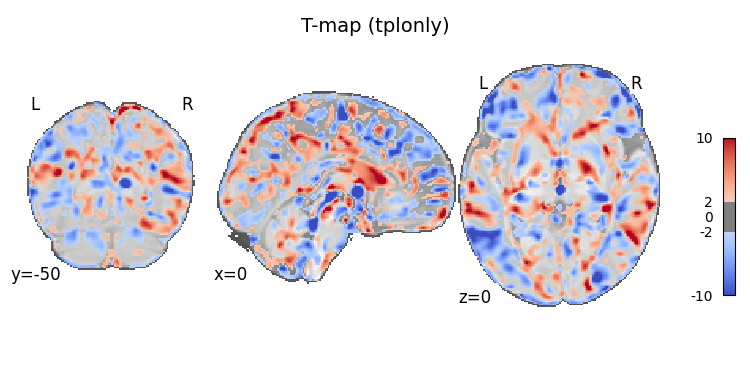

Saved /project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/tmap_bias_log_JD_00_to_01_onlydHCP_test_tplonly.png
Plotting: avgsubj
FDR t-threshold: 5.8713


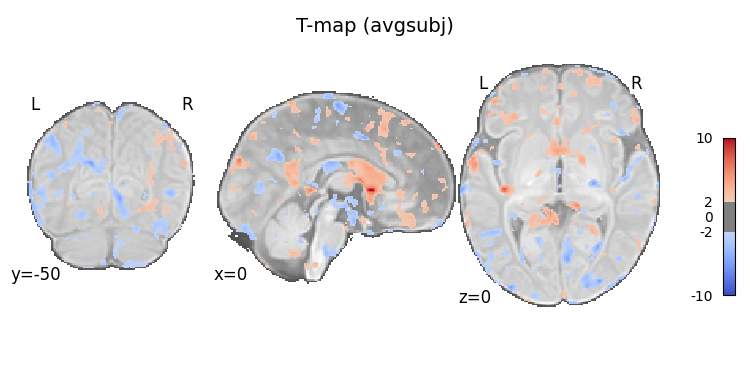

Saved /project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/tmap_bias_log_JD_00_to_01_onlydHCP_test_avgsubj.png
Processing dataset: iso

===== Processing age window: 0-1M =====

🧠 tpl_fix=01M — Significance summary
  Total voxels: 1,192,993
  Raw p<0.05 = 687,672 (57.64%), FDR<0.05 = 618,342 (51.83%)
FDR t-threshold: 2.4910
Saved maps for tplonly

🧠 tpl_fix=01M — Significance summary
  Total voxels: 1,192,993
  Raw p<0.05 = 207,447 (17.39%), FDR<0.05 = 9,399 (0.79%)
FDR t-threshold: 4.6242
Saved maps for avgsubj
Plotting: tplonly
FDR t-threshold: 2.4910


/scratch/yapwan/slurm_job_51370287/ipykernel_3769033/1937703579.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


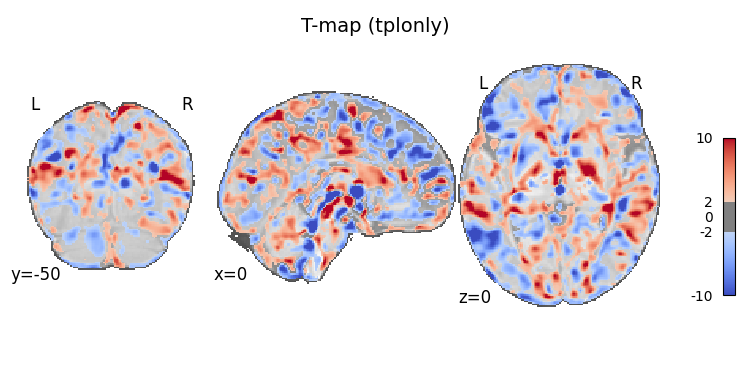

Saved /project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/tmap_bias_log_JD_00_to_01_onlyiso_test_tplonly.png
Plotting: avgsubj
FDR t-threshold: 4.6242


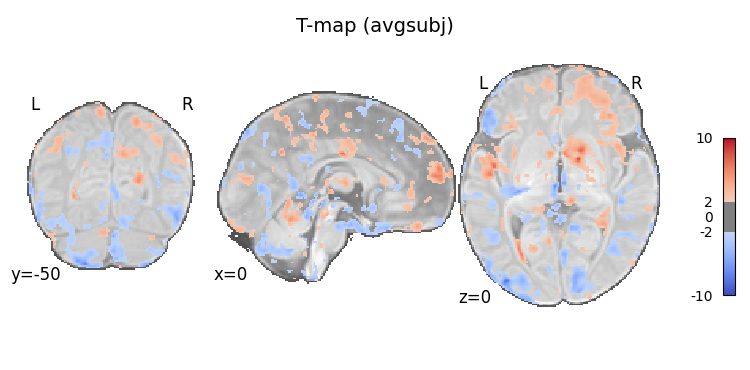

Saved /project/4290000.01/yapwan/Projects/NeonatalNormalization/Result/tmap_bias_log_JD_00_to_01_onlyiso_test_avgsubj.png


In [9]:
# ======== Config ======== #
modalities = ["T1", "T2"]
pipel_dir = "/project/4290000.01/yapwan/Projects/CerebellarNormalization_1002/pipeline/ants_normalize"
pipel_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Data"
tpl_root = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"
tpl_trans_dir = f"{tpl_root}/tpl_xfm_build"


# ================= CONFIG ================= #
result_dir = "/project/4290000.01/yapwan/Projects/NeonatalNormalization/Result"
tpl_root    = "/project/4290000.01/yapwan/toolbox/BCP-atlas-for_release-Ver2.0.0"

methods = ["tplonly", "avgsubj"]

for dataset_name in ['dHCP','iso']:
    print(f"Processing dataset: {dataset_name}")
    info_age = pd.read_csv(os.path.join(Info_dir, f'{dataset_name}_participants.tsv'), sep='\t')
    window_cols = [c for c in info_age.columns if "-" in c and c.endswith("M")]
    subs = {}
    for m_bin in window_cols[:1]:
        print(f"\n===== Processing age window: {m_bin} =====")
        tpl_mov_month = m_bin.replace("M","").split("-")[0].zfill(2)
        tpl_fix_month = m_bin.replace("M","").split("-")[1].zfill(2)
        

        ref_img  = nib.load(get_tpl_path(tpl_fix_month, "T1"))
        mask_img = nib.load(get_tpl_path(tpl_fix_month, "T1").replace("-T1.nii.gz", "-Mask.nii.gz"))
        mask = mask_img.get_fdata() > 0

        file_key = f"log_JD_{tpl_mov_month}_to_{tpl_fix_month}_only{dataset_name}_test"

        # Load bias arrays once
        bias_dt = np.load(os.path.join(result_dir, f"all_bias_{file_key}_tplonly.npy"))
        bias_as = np.load(os.path.join(result_dir, f"all_bias_{file_key}_avgsubj.npy"))


        df = bias_dt.shape[0] - 1  # df for t-test

        # Pre-store everything for visualization
        t_results = {}
        p_results = {}

        # ---------- Compute t-test and save maps ---------- #
        for method, bias in zip(methods, [bias_dt, bias_as]):

            # t-test
            tvals, pvals = one_sample_ttest(bias)
            t_results[method] = tvals
            p_results[method] = pvals

            # FDR
            reject, qvals = fdr_bh(pvals, alpha=0.05)

            # Mean bias
            mean_bias = bias.mean(axis=0)
            sig_mean_bias = np.where(reject, mean_bias, 0)

            # ======== Summary ======== #
            total_voxels = np.sum(mask)
            raw_sig = np.sum(pvals < 0.05)
            fdr_sig = np.sum(reject)
            print(f"\n🧠 tpl_fix={tpl_fix_month}M — Significance summary")
            print(f"  Total voxels: {total_voxels:,}")
            print(f"  Raw p<0.05 = {raw_sig:,} ({raw_sig/total_voxels*100:.2f}%), "
                f"FDR<0.05 = {fdr_sig:,} ({fdr_sig/total_voxels*100:.2f}%)")

            # FDR t-threshold
            t_thr = compute_fdr_t_threshold(tvals, pvals, alpha=0.05, df=df)
            if t_thr is None:
                t_thr = 1.96
            print(f"FDR t-threshold: {t_thr:.4f}")

            
            # Save
            save_nifti(tvals, mask, ref_img, os.path.join(result_dir, f"tmap_bias_{file_key}_{method}.nii.gz"))
            save_nifti(pvals, mask, ref_img, os.path.join(result_dir, f"pmap_bias_{file_key}_{method}.nii.gz"))
            save_nifti(qvals, mask, ref_img, os.path.join(result_dir, f"qmap_bias_{file_key}_{method}_fdr05.nii.gz"))
            save_nifti(reject.astype(np.uint8), mask, ref_img,
                    os.path.join(result_dir, f"sigmask_bias_{file_key}_{method}_fdr05.nii.gz"))

            save_nifti(mean_bias,      mask, ref_img, os.path.join(result_dir, f"bias_mean_{file_key}_{method}.nii.gz"))
            save_nifti(sig_mean_bias,  mask, ref_img,
                    os.path.join(result_dir, f"bias_mean_sig_{file_key}_{method}_fdr05.nii.gz"))

            print(f"Saved maps for {method}")

        # ---------- Visualization (FDR threshold) ---------- #
        bg_img = get_tpl_path(tpl_fix_month, "T1")

        for method in methods:

            print(f"Plotting: {method}")

            tvals = t_results[method]
            pvals = p_results[method]

            # FDR t-threshold
            t_thr = compute_fdr_t_threshold(tvals, pvals, alpha=0.05, df=df)
            if t_thr is None:
                t_thr = 1.96

            # Plot
            print(f"FDR t-threshold: {t_thr:.4f}")
            display = plotting.plot_stat_map(
                os.path.join(result_dir, f"tmap_bias_{file_key}_{method}.nii.gz"),
                bg_img=bg_img,
                # threshold=t_thr,
                threshold=1.96,
                vmin=-10, vmax=10,
                cmap='coolwarm',
                draw_cross=False,
                black_bg=False,
                display_mode='ortho',
                cut_coords=[0, -50, 0]
            )

            # Adjust colorbar
            cbar_ax = getattr(display, "_cbar_ax", getattr(display, "_colorbar_ax", None))
            pos = cbar_ax.get_position()
            cbar_ax.set_position([pos.x0, pos.y0 + 0.15 * pos.height, pos.width, pos.height * 0.5])

            # Title
            fig = getattr(display, "_fig", plt.gcf())
            plt.tight_layout(rect=[0, 0, 1, 0.94])
            fig.suptitle(f"T-map ({method})", y=0.98, fontsize=14)

            out_png = os.path.join(result_dir, f"tmap_bias_{file_key}_{method}_FDRthr.png")
            out_png = os.path.join(result_dir, f"tmap_bias_{file_key}_{method}.png")
            plt.savefig(out_png, dpi=300, bbox_inches="tight")
            plt.show()

            print(f"Saved {out_png}")